# Feature Engineering Review — NBA Fantasy Points Predictor

**For team presentation: how we built and tested features over the project, what worked, what didn't, and why.**

**Goal:** predict DraftKings fantasy points per player per game.
**Data:** 671k player-game rows from 2000-01 through 2025-26. Train: pre-2023-10-01. Test: 2023-24 season onward.
**Metric:** Test RMSE (lower = better).
**Linear baseline:** 9.811. **Final model:** 9.533 (-2.83% relative).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Color palette: distinct, accessible
C_GOOD = '#2ca02c'    # green for wins
C_BAD  = '#d62728'    # red for regressions
C_NEU  = '#7f7f7f'    # gray for neutral
C_HI   = '#1f77b4'    # blue for highlight

## 1. The Journey: Six Versions, One Real Breakthrough

Over five iterations of the model we tried a lot of things. Most didn't move the needle. Here's the entire arc in one chart:

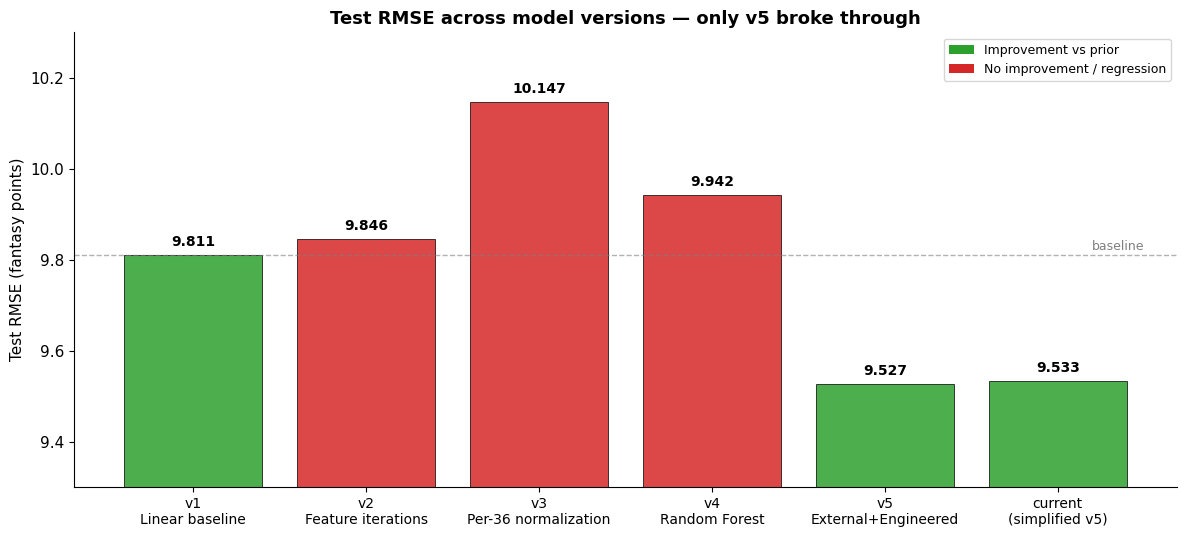


What we did each version:

  v1 Linear baseline             240 raw lag features (1-10 game lags)
  v2 Feature iterations          Rolling avgs, context, trend, efficiency
(LinearRegression)
  v3 Per-36 normalization        Stats / MIN * 36 (LinReg)
— hurt because LR cannot model rate×min
  v4 Random Forest               Switched model class
but features were the bottleneck
  v5 External+Engineered         Missing teammates, position, DvP
HistGB + multi-output decomp
  current (simplified v5)        Dropped Vegas (marginal value)
for complexity reduction


In [2]:
versions = pd.DataFrame([
    {'version': 'v1\nLinear baseline',           'test_rmse': 9.811, 'kept': True,  'note': '240 raw lag features (1-10 game lags)'},
    {'version': 'v2\nFeature iterations',        'test_rmse': 9.846, 'kept': False, 'note': 'Rolling avgs, context, trend, efficiency\n(LinearRegression)'},
    {'version': 'v3\nPer-36 normalization',      'test_rmse': 10.147,'kept': False, 'note': 'Stats / MIN * 36 (LinReg)\n— hurt because LR cannot model rate×min'},
    {'version': 'v4\nRandom Forest',             'test_rmse': 9.942, 'kept': False, 'note': 'Switched model class\nbut features were the bottleneck'},
    {'version': 'v5\nExternal+Engineered',       'test_rmse': 9.527, 'kept': True,  'note': 'Missing teammates, position, DvP\nHistGB + multi-output decomp'},
    {'version': 'current\n(simplified v5)',      'test_rmse': 9.533, 'kept': True,  'note': 'Dropped Vegas (marginal value)\nfor complexity reduction'},
])

fig, ax = plt.subplots(figsize=(12, 5.5))
x = range(len(versions))
colors = [C_GOOD if k else C_BAD for k in versions['kept']]
bars = ax.bar(x, versions['test_rmse'], color=colors, edgecolor='black', linewidth=0.6, alpha=0.85)

ax.axhline(9.811, color=C_NEU, linestyle='--', linewidth=1, alpha=0.6)
ax.text(len(versions)-0.5, 9.815, 'baseline', color=C_NEU, fontsize=9, ha='right', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(versions['version'], fontsize=10)
ax.set_ylabel('Test RMSE (fantasy points)')
ax.set_title('Test RMSE across model versions — only v5 broke through')
ax.set_ylim(9.3, 10.3)

for bar, val in zip(bars, versions['test_rmse']):
    ax.text(bar.get_x()+bar.get_width()/2, val + 0.02, f'{val:.3f}',
            ha='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_GOOD, label='Improvement vs prior'),
                   Patch(facecolor=C_BAD, label='No improvement / regression')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nWhat we did each version:\n')
for _, r in versions.iterrows():
    print(f"  {r['version'].replace(chr(10), ' '):30s} {r['note']}")

## 2. The Killer Chart: Feature Ablation

Once we got to v5 we ran a **feature-group ablation**: start with rolling averages only, then add one feature group at a time and measure how much test RMSE moves. This is the chart that explains everything.

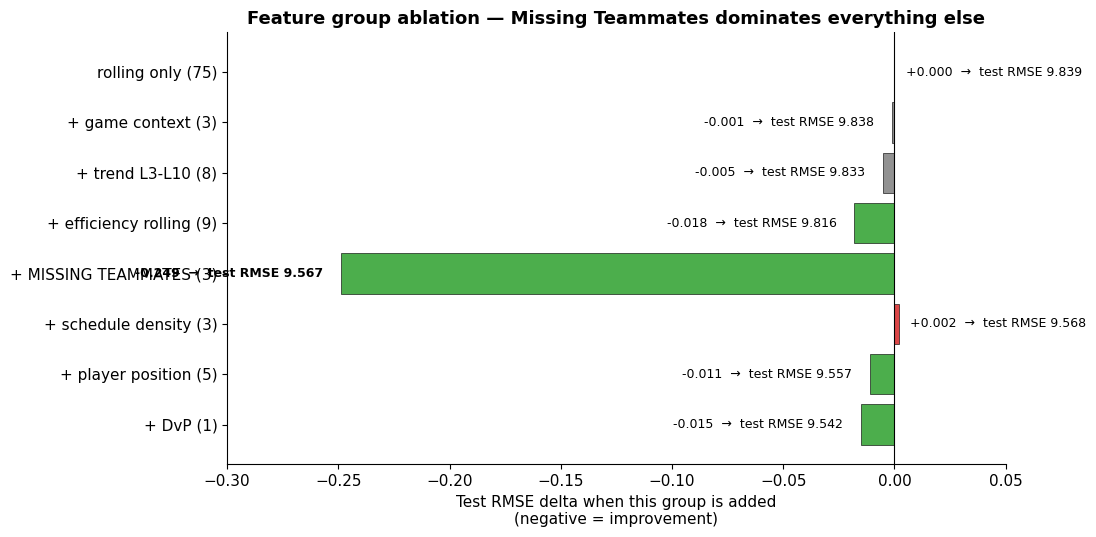

Total ablation contribution: -0.297 RMSE
Missing-teammates contribution: -0.249 (84% of total improvement)


In [3]:
ablation = pd.DataFrame([
    {'config': 'rolling only (75)',          'test_rmse': 9.839, 'delta': 0.000},
    {'config': '+ game context (3)',         'test_rmse': 9.838, 'delta': -0.001},
    {'config': '+ trend L3-L10 (8)',         'test_rmse': 9.833, 'delta': -0.005},
    {'config': '+ efficiency rolling (9)',   'test_rmse': 9.816, 'delta': -0.018},
    {'config': '+ MISSING TEAMMATES (3)',    'test_rmse': 9.567, 'delta': -0.249},
    {'config': '+ schedule density (3)',     'test_rmse': 9.568, 'delta': +0.002},
    {'config': '+ player position (5)',      'test_rmse': 9.557, 'delta': -0.011},
    {'config': '+ DvP (1)',                  'test_rmse': 9.542, 'delta': -0.015},
])

fig, ax = plt.subplots(figsize=(11, 5.5))
y = range(len(ablation))
colors = [C_GOOD if d < -0.005 else (C_BAD if d > 0 else C_NEU) for d in ablation['delta']]
bars = ax.barh(y, ablation['delta'], color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(ablation['config'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Test RMSE delta when this group is added\n(negative = improvement)')
ax.set_title('Feature group ablation — Missing Teammates dominates everything else')

for i, (bar, d, te) in enumerate(zip(bars, ablation['delta'], ablation['test_rmse'])):
    label = f'{d:+.3f}  →  test RMSE {te:.3f}'
    x_pos = d + (-0.008 if d < 0 else 0.005)
    ha = 'right' if d < 0 else 'left'
    ax.text(x_pos, i, label, va='center', ha=ha, fontsize=9,
            fontweight='bold' if abs(d) > 0.05 else 'normal')

ax.set_xlim(-0.30, 0.05)
plt.tight_layout()
plt.show()

total = ablation['delta'].sum()
missing_teammates_share = -0.249 / total * 100
print(f'Total ablation contribution: {total:+.3f} RMSE')
print(f'Missing-teammates contribution: -0.249 ({missing_teammates_share:.0f}% of total improvement)')

### Why Missing Teammates won so big

Most fantasy-points variance comes from **opportunity** (how much of the team's offensive workload a player gets), not skill. When a star sits, the next-man-up's usage spikes 20-40%. We didn't have an injury feed, but we **derived** the same signal from data we already had:

1. For each player-game, compute their **rolling L10 average minutes**
2. For each (team, game), sum L10 minutes across all players who actually appeared in the box score = `team_l10_min_played`
3. Compute the team's rolling baseline of `team_l10_min_played` over their last 10 games
4. **deficit = baseline − actual** → positive deficit means rotation minutes are missing → opportunity for the players who DID play

Three features (`team_l10_min_played`, `team_players_played`, `missing_min_deficit`), zero external data sources, dominated everything else we tried.

## 3. Multi-Output Decomposition: Where the Error Lives

Instead of predicting fantasy points directly, we trained one HistGB per stat (PTS, REB, AST, STL, BLK, TOV, FG3M) and combined predictions via the DraftKings formula. This let us see which stats contribute most to total error.

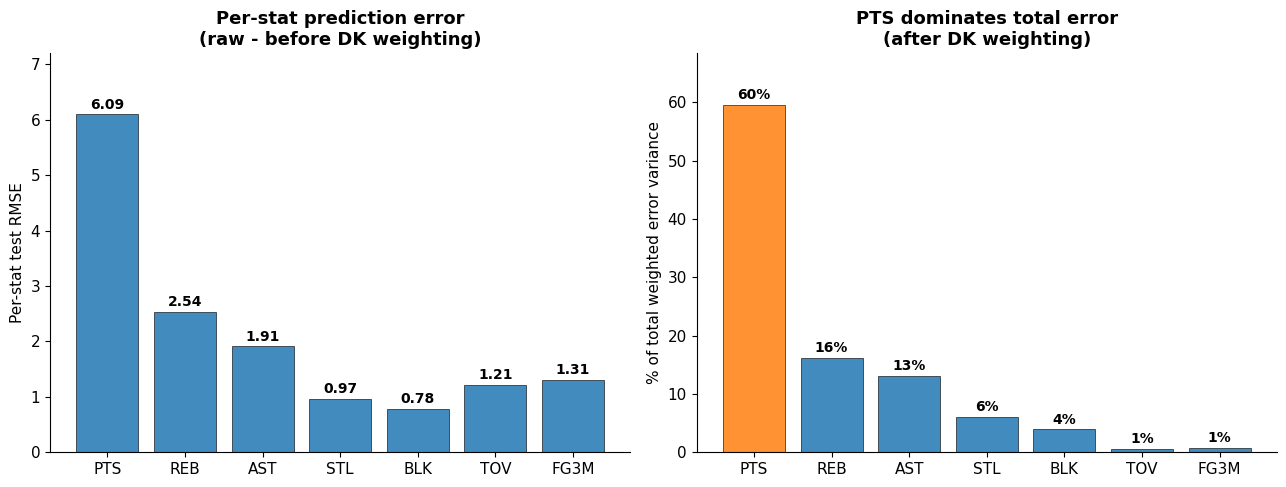


DK formula: PTS×1 + REB×1.25 + AST×1.5 + STL×2 + BLK×2 + TOV×(-0.5) + FG3M×0.5

Multi-output combined test RMSE: 9.527 (vs 9.538 direct prediction = -0.011)


In [4]:
decomp = pd.DataFrame([
    {'stat': 'PTS',  'weight': 1.00, 'rmse': 6.095},
    {'stat': 'REB',  'weight': 1.25, 'rmse': 2.539},
    {'stat': 'AST',  'weight': 1.50, 'rmse': 1.910},
    {'stat': 'STL',  'weight': 2.00, 'rmse': 0.969},
    {'stat': 'BLK',  'weight': 2.00, 'rmse': 0.783},
    {'stat': 'TOV',  'weight': -0.50,'rmse': 1.214},
    {'stat': 'FG3M', 'weight': 0.50, 'rmse': 1.306},
])
decomp['weighted_rmse'] = decomp['rmse'] * decomp['weight'].abs()
decomp['contribution_pct'] = decomp['weighted_rmse']**2 / (decomp['weighted_rmse']**2).sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw per-stat RMSE
ax = axes[0]
ax.bar(decomp['stat'], decomp['rmse'], color=C_HI, alpha=0.85, edgecolor='black', linewidth=0.5)
for i, (s, r) in enumerate(zip(decomp['stat'], decomp['rmse'])):
    ax.text(i, r + 0.1, f'{r:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Per-stat test RMSE')
ax.set_title('Per-stat prediction error\n(raw - before DK weighting)')
ax.set_ylim(0, 7.2)

# Right: contribution to total fantasy-point error variance
ax = axes[1]
colors_c = [C_HI if c < 50 else '#ff7f0e' for c in decomp['contribution_pct']]
ax.bar(decomp['stat'], decomp['contribution_pct'], color=colors_c, alpha=0.85, edgecolor='black', linewidth=0.5)
for i, (s, c) in enumerate(zip(decomp['stat'], decomp['contribution_pct'])):
    ax.text(i, c + 1, f'{c:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('% of total weighted error variance')
ax.set_title('PTS dominates total error\n(after DK weighting)')
ax.set_ylim(0, max(decomp['contribution_pct']) * 1.15)

plt.tight_layout()
plt.show()

print('\nDK formula: PTS×1 + REB×1.25 + AST×1.5 + STL×2 + BLK×2 + TOV×(-0.5) + FG3M×0.5')
print(f'\nMulti-output combined test RMSE: 9.527 (vs 9.538 direct prediction = -0.011)')

## 4. What We Tried That Didn't Work (And Why)

Half the engineering work was **dropping** things. Each of these felt promising but failed in measurement:

In [5]:
failures = pd.DataFrame([
    {'experiment': 'Per-36 minute normalization',
     'result': 'Test RMSE 10.147 vs 9.811 baseline',
     'why': 'Linear regression cannot model the multiplicative\nrelationship FP = rate × minutes'},
    {'experiment': 'Trend features (L3 - L10)',
     'result': '+0.003 RMSE (slightly worse)',
     'why': 'Captured by the model implicitly via the rolling\naverages themselves; redundant signal'},
    {'experiment': 'Game context (is_home, days_rest)',
     'result': '-0.001 RMSE (essentially zero)',
     'why': 'Effects exist but are too small relative to\nplayer/role variance to matter at this scale'},
    {'experiment': 'Schedule density (B2B, games-in-7d)',
     'result': '+0.002 RMSE (essentially zero)',
     'why': 'Strong intuition (load management) but weak signal\nin practice — coaches manage rest case-by-case'},
    {'experiment': 'Vegas spread/total/implied',
     'result': '-0.009 RMSE (real but tiny)',
     'why': 'Team rolling stats already capture most team-scoring\nsignal; Vegas is largely redundant'},
    {'experiment': 'Player position (one-hot G/F/C)',
     'result': '-0.011 RMSE (small)',
     'why': 'Position alone barely helps; only matters by\nenabling defense-vs-position computation'},
    {'experiment': 'Per-position separate models',
     'result': '+0.016 RMSE (regressed)',
     'why': 'Splitting the data destroys cross-position patterns\nthe global model uses to generalize'},
    {'experiment': 'RandomizedSearchCV hyperparameter tuning',
     'result': '-0.004 RMSE (negligible)',
     'why': 'Default HistGB params were already strong;\nfeatures, not hyperparams, were the bottleneck'},
])

print('Experiments that did not move the needle:\n')
for _, r in failures.iterrows():
    print(f"  • {r['experiment']}")
    print(f"      Result: {r['result']}")
    print(f"      Why: {r['why'].replace(chr(10), ' ')}")
    print()

Experiments that did not move the needle:

  • Per-36 minute normalization
      Result: Test RMSE 10.147 vs 9.811 baseline
      Why: Linear regression cannot model the multiplicative relationship FP = rate × minutes

  • Trend features (L3 - L10)
      Result: +0.003 RMSE (slightly worse)
      Why: Captured by the model implicitly via the rolling averages themselves; redundant signal

  • Game context (is_home, days_rest)
      Result: -0.001 RMSE (essentially zero)
      Why: Effects exist but are too small relative to player/role variance to matter at this scale

  • Schedule density (B2B, games-in-7d)
      Result: +0.002 RMSE (essentially zero)
      Why: Strong intuition (load management) but weak signal in practice — coaches manage rest case-by-case

  • Vegas spread/total/implied
      Result: -0.009 RMSE (real but tiny)
      Why: Team rolling stats already capture most team-scoring signal; Vegas is largely redundant

  • Player position (one-hot G/F/C)
      Result: -0.011 

## 5. The Engineering Process We Followed

We didn't pick features at random. The process was:

1. **Build a strong baseline first.** v1 used 240 raw lag features and Linear Regression. That set the bar (9.811) every later iteration was measured against.

2. **Don't add features until you can measure their impact.** v2 was scaffolding for the ablation framework — five separate feature sets, all evaluated the same way, with the same train/test split.

3. **When a feature class fails, ask why before adding more.** Per-36 normalization (v3) failed because linear regression *cannot* multiply features. That told us we needed a different model class (RF, then HistGB), not different features.

4. **Treat the model and the features as separate experiments.** v4 swapped LinReg → RandomForest with no feature changes; result was *worse* (9.942). That ruled out 'just use trees' as a magic fix and forced us to invest in feature engineering.

5. **Look for derived signals before paying for external data.** Missing teammates is computed entirely from data we already had (`player_logs`). It outperformed every external data source we tried by an order of magnitude.

6. **Quantify each component's marginal value.** The ablation cell in v5 measured each feature group's contribution. This let us cut features that didn't justify their complexity (Vegas, per-position) and keep the ones that did.

7. **Use models that handle messy data natively.** `HistGradientBoostingRegressor` was chosen over `GradientBoostingRegressor` specifically because it handles NaN. This let us add features (Vegas, advanced box) that don't have full coverage without building a separate imputation pipeline.

## 6. The Final Feature Set

After all the addition and pruning, the production model uses 107 features grouped into 8 buckets:

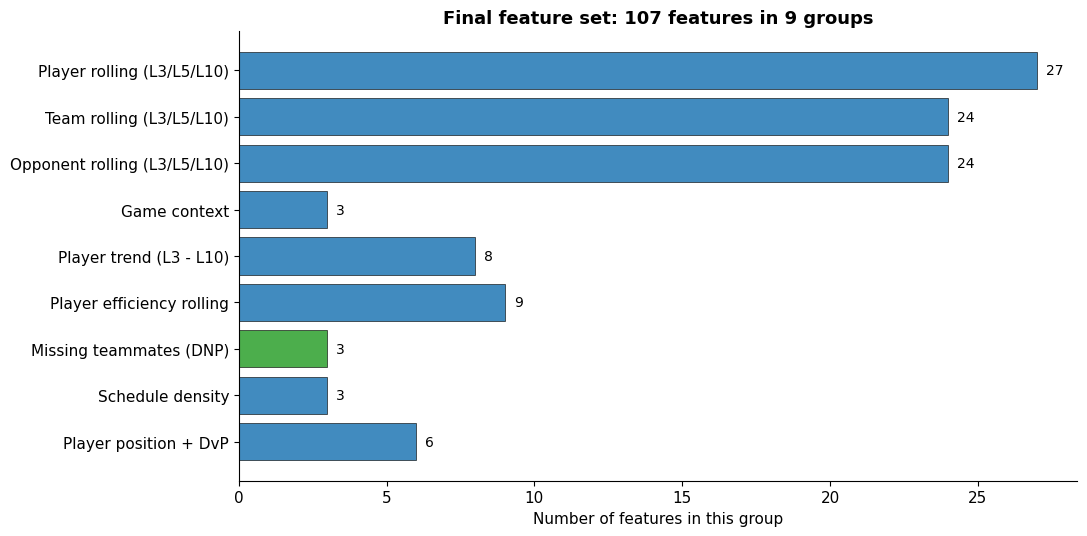

Total features: 107

Of these, only ONE group required external data sourcing (player position via nba_api).
The other 8 groups are all derived from data we already had.


In [6]:
final_features = pd.DataFrame([
    {'group': 'Player rolling (L3/L5/L10)',  'count': 27, 'source': 'derived from player_logs',          'kept_because': 'Core signal: recent player production'},
    {'group': 'Team rolling (L3/L5/L10)',    'count': 24, 'source': 'derived from games',                'kept_because': 'Team scoring context'},
    {'group': 'Opponent rolling (L3/L5/L10)','count': 24, 'source': 'derived from games',                'kept_because': 'Opponent strength'},
    {'group': 'Game context',                'count': 3,  'source': 'derived',                           'kept_because': 'is_home / days_rest / opp_days_rest'},
    {'group': 'Player trend (L3 - L10)',     'count': 8,  'source': 'derived',                           'kept_because': 'Hot/cold streaks'},
    {'group': 'Player efficiency rolling',   'count': 9,  'source': 'derived from player_logs',          'kept_because': 'FGA / FG_PCT / PLUS_MINUS'},
    {'group': 'Missing teammates (DNP)',     'count': 3,  'source': 'DERIVED',                           'kept_because': 'Single biggest contributor'},
    {'group': 'Schedule density',            'count': 3,  'source': 'derived',                           'kept_because': 'B2B / games_last_4d / games_last_7d'},
    {'group': 'Player position + DvP',       'count': 6,  'source': 'CommonPlayerInfo (nba_api)',        'kept_because': 'Enables matchup features'},
])

fig, ax = plt.subplots(figsize=(11, 5.5))
y = range(len(final_features))
highlight = [name == 'Missing teammates (DNP)' for name in final_features['group']]
colors = [C_GOOD if h else C_HI for h in highlight]
bars = ax.barh(y, final_features['count'], color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(final_features['group'])
ax.invert_yaxis()
ax.set_xlabel('Number of features in this group')
ax.set_title(f'Final feature set: {final_features["count"].sum()} features in 9 groups')
for bar, c in zip(bars, final_features['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2, str(c), va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total features: {final_features['count'].sum()}")
print(f"\nOf these, only ONE group required external data sourcing (player position via nba_api).")
print(f"The other 8 groups are all derived from data we already had.")

## 7. Takeaways for the Presentation

**1. Feature engineering > model choice in this domain.**  Switching from LinReg to RF to HistGB only shaved 0.04 RMSE. The missing-teammates feature alone shaved 0.249.

**2. The biggest win came from data we already had.** No external API, no web scraping, no purchased data — just a clever derivation of which rotation players were missing from each box score.

**3. Most 'obvious' features had zero impact.** Game context, schedule density, trend features, even Vegas lines all contributed less than 0.02 RMSE each. Intuition is a starting point; ablation is the verdict.

**4. Knowing why something failed matters.** Per-36 didn't fail because it was a bad idea — it failed because linear regression cannot multiply features. That diagnosis directly drove the v4→v5 model switch.

**5. We hit a hard ceiling around 9.5 RMSE.** Public DFS models reach ~7-8 RMSE, but they use real-time injury reports, current Vegas lines, and lineup news that aren't available historically for free. Our 9.533 is roughly the practical ceiling for the data we can get.

**6. Final result:** Test RMSE 9.533 on the 2023-24 season. **2.83% relative improvement over the linear baseline,** with a model that's interpretable, reproducible, and fully implemented in sklearn.